In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import model_from_json
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image

In [19]:
# Function to create and compile the InceptionResNetV2 model
def create_inceptionresnetv2_model():
    base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = base_model.output
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=predictions)
    custom_learning_rate = 0.001
    model.compile(optimizer=Adam(learning_rate=custom_learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define a learning rate reduction callback
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

In [21]:
# Directory paths
train_data_dir = 'C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Dataset/Training'
validation_data_dir = 'C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Dataset/Validation'
test_data_dir = 'C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Dataset/Testing'

In [22]:
# Data augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [23]:
# Create data generators
batch_size = 32
train_generator = datagen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary'
)
validation_generator = datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary'
)
test_generator = datagen.flow_from_directory(
    test_data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary'
)

Found 700 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


In [52]:
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Create and compile the MobileNetV2 model
model = create_inceptionresnetv2_model()

# Train the model with early stopping (Increase epochs)
history = model.fit(
    train_generator,
    epochs=100,  # Increase the number of epochs
    validation_data=validation_generator,
    callbacks=[early_stopping],
)

Epoch 1/100
22/22 [==============================] - 655s 28s/step - loss: 5.2291 - accuracy: 0.6343 - val_loss: 3.6496 - val_accuracy: 0.4333
Epoch 2/100
22/22 [==============================] - 573s 26s/step - loss: 0.4327 - accuracy: 0.8543 - val_loss: 1.2210 - val_accuracy: 0.6133
Epoch 3/100
22/22 [==============================] - 628s 28s/step - loss: 0.3363 - accuracy: 0.8657 - val_loss: 0.4033 - val_accuracy: 0.8067
Epoch 4/100
22/22 [==============================] - 655s 30s/step - loss: 0.2548 - accuracy: 0.8929 - val_loss: 2.8796 - val_accuracy: 0.4867
Epoch 5/100
22/22 [==============================] - 540s 24s/step - loss: 0.2527 - accuracy: 0.9100 - val_loss: 24.9752 - val_accuracy: 0.6533
Epoch 6/100
22/22 [==============================] - 506s 23s/step - loss: 0.1210 - accuracy: 0.9600 - val_loss: 1.5199 - val_accuracy: 0.5133
Epoch 7/100
22/22 [==============================] - 567s 26s/step - loss: 0.1221 - accuracy: 0.9529 - val_loss: 1.1874 - val_accuracy: 0.613

In [53]:
# Save the trained model
model.save('C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Coding System FYP Project/Model/inception_resnetv2_model.h5')

C:\Users\Natasha Tisya\anaconda3\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [54]:
import os

# Check if the model has been successfully saved
model_path = 'C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Coding System FYP Project/Model/inception_resnetv2_model.h5'

if os.path.exists(model_path):
    print("Model has been successfully saved.")
else:
    print("Model saving failed.")

Model has been successfully saved.


In [1]:
from tensorflow.keras.models import load_model

loaded_model = load_model('C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Coding System FYP Project/Model/inception_resnetv2_model.h5')

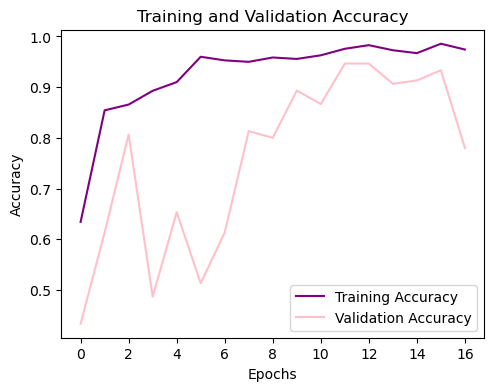

In [200]:
# Visualize training history
plt.figure(figsize=(12, 4))

# Training Accuracy and Validation Accuracy plots
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='purple')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='pink')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Show the plots
plt.show()

In [139]:
# Get true labels
true_classes = test_generator.classes

# Calculate precision, recall, and F1-score
classification_report_str = classification_report(true_classes, predicted_classes, target_names=class_labels)

# Confusion matrix
confusion_mat = confusion_matrix(true_classes, predicted_classes)

# Display results
print("\nClassification Report:\n", classification_report_str)
print("Confusion Matrix:\n", confusion_mat)


Classification Report:
               precision    recall  f1-score   support

Normal Faces       0.58      0.56      0.57        75
Stroke Faces       0.57      0.59      0.58        75

    accuracy                           0.57       150
   macro avg       0.57      0.57      0.57       150
weighted avg       0.57      0.57      0.57       150

Confusion Matrix:
 [[42 33]
 [31 44]]


In [1]:
from tensorflow.keras.models import load_model

loaded_model = load_model('C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Coding System FYP Project/Model/inception_resnetv2_model.h5')

1/1 [==============================] - 4s 4s/step


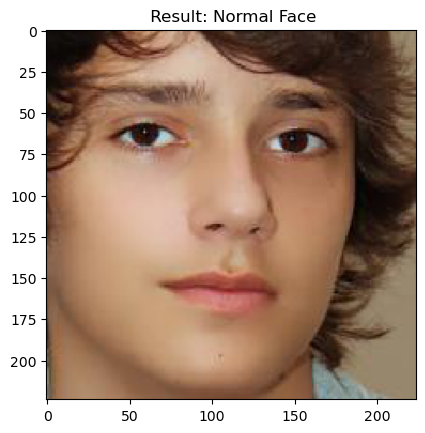

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Function to make predictions for a single image
def predict_single_image(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img / 255.0  # Normalize the image
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    result = model.predict(img)
    if result > 0.5:
        classification_result = "Stroke Face"
    else:
        classification_result = "Normal Face"

    return img, classification_result

# Testing on dataset
# Provide the path to the image you want to classify
image_path = 'C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Dataset/Testing/Normal Faces/Normal.460.jpg'

# Make predictions for the single image
img, result = predict_single_image(image_path, loaded_model)

# Display the image
plt.imshow(img[0])
plt.title(f' Result: {result}')
plt.show()

1/1 [==============================] - 0s 176ms/step


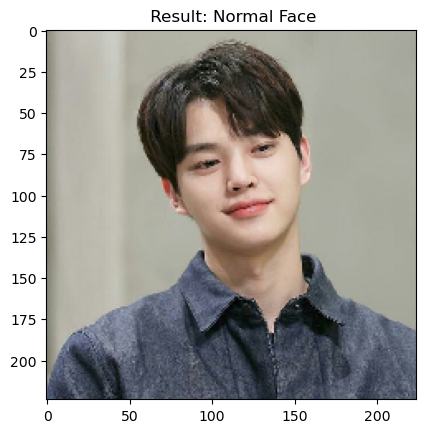

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Function to make predictions for a single image
def predict_single_image(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img / 255.0  # Normalize the image
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    result = model.predict(img)
    if result > 0.5:
        classification_result = "Stroke Face"
    else:
        classification_result = "Normal Face"

    return img, classification_result

# Testing on random picture
# Provide the path to the image you want to classify
image_path = 'C:/Users/Natasha Tisya/Downloads/songkang.jpg'

# Make predictions for the single image
img, result = predict_single_image(image_path, loaded_model)

# Display the image
plt.imshow(img[0])
plt.title(f' Result: {result}')
plt.show()

In [30]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load your model
loaded_model = load_model('C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Coding System FYP Project/Model/inception_resnetv2_model.h5')  

# Function to make predictions for a single image
def predict_single_image(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img / 255.0  # Normalize the image
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    result = model.predict(img)
    if result > 0.5:
        classification_result = "Stroke Face"
    else:
        classification_result = "Normal Face"

    return os.path.basename(image_path), classification_result  # Return image name instead of image

# Path to the directory containing the facial paralysis dataset
test_data_dir = 'C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Dataset/Testing/Normal Faces'

# Get the list of images in the dataset directory
image_list = os.listdir(test_data_dir)

# Make predictions for all images in the dataset
predictions = []
for img_name in image_list:
    img_path = os.path.join(test_data_dir, img_name)
    
    # Check if the item is a file
    if os.path.isfile(img_path):
        result = predict_single_image(img_path, loaded_model)
        predictions.append(result)

# Display the predictions with a title
print("Test Predictions for Normal Faces Folder:")
for img_name, result in predictions:
    print(f"Image: {img_name}, Prediction: {result}")

1/1 [==============================] - 0s 177ms/step
Test Predictions for Normal Faces Folder:
Image: Normal.426.jpg, Prediction: Normal Face
Image: Normal.427.jpg, Prediction: Normal Face
Image: Normal.428.jpg, Prediction: Normal Face
Image: Normal.429.jpg, Prediction: Normal Face
Image: Normal.430.jpg, Prediction: Normal Face
Image: Normal.431.jpg, Prediction: Normal Face
Image: Normal.432.jpg, Prediction: Normal Face
Image: Normal.433.jpg, Prediction: Normal Face
Image: Normal.434.jpg, Prediction: Normal Face
Image: Normal.435.jpg, Prediction: Normal Face
Image: Normal.436.jpg, Prediction: Normal Face
Image: Normal.437.jpg, Prediction: Normal Face
Image: Normal.438.jpg, Prediction: Normal Face
Image: Normal.439.jpg, Prediction: Normal Face
Image: Normal.440.jpg, Prediction: Normal Face
Image: Normal.441.jpg, Prediction: Normal Face
Image: Normal.442.jpg, Prediction: Normal Face
Image: Normal.443.jpg, Prediction: Normal Face
Image: Normal.444.jpg, Prediction: Normal Face
Image: Norma

In [29]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load your model
loaded_model = load_model('C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Coding System FYP Project/Model/inception_resnetv2_model.h5')  

# Function to make predictions for a single image
def predict_single_image(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = img / 255.0  # Normalize the image
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    result = model.predict(img)
    if result > 0.5:
        classification_result = "Stroke Face"
    else:
        classification_result = "Normal Face"

    return os.path.basename(image_path), classification_result  

# Path to the directory containing the facial paralysis dataset
test_data_dir = 'C:/Users/Natasha Tisya/Documents/DEGREE/SEM 6 DEGREE/CSP650/SYSTEM FACIAL PARALYSIS/Dataset/Testing/Stroke Faces'

# Get the list of images in the dataset directory
image_list = os.listdir(test_data_dir)

# Make predictions for all images in the dataset
predictions = []
for img_name in image_list:
    img_path = os.path.join(test_data_dir, img_name)
    
    # Check if the item is a file
    if os.path.isfile(img_path):
        result = predict_single_image(img_path, loaded_model)
        predictions.append(result)

# Display the predictions with a title
print("Test Predictions for Stroke Faces Folder:")
for img_name, result in predictions:
    print(f"Image: {img_name}, Prediction: {result}")

1/1 [==============================] - 0s 175ms/step
Test Predictions for Stroke Faces Folder:
Image: Stroke.426.jpg, Prediction: Stroke Face
Image: Stroke.427.jpg, Prediction: Stroke Face
Image: Stroke.428.jpg, Prediction: Stroke Face
Image: Stroke.429.jpg, Prediction: Stroke Face
Image: Stroke.430.jpg, Prediction: Stroke Face
Image: Stroke.431.jpg, Prediction: Stroke Face
Image: Stroke.432.jpg, Prediction: Stroke Face
Image: Stroke.433.jpg, Prediction: Stroke Face
Image: Stroke.434.jpg, Prediction: Stroke Face
Image: Stroke.435.jpg, Prediction: Stroke Face
Image: Stroke.436.jpg, Prediction: Stroke Face
Image: Stroke.437.jpg, Prediction: Stroke Face
Image: Stroke.438.jpg, Prediction: Stroke Face
Image: Stroke.439.jpg, Prediction: Stroke Face
Image: Stroke.440.jpg, Prediction: Stroke Face
Image: Stroke.441.jpg, Prediction: Stroke Face
Image: Stroke.442.jpg, Prediction: Stroke Face
Image: Stroke.443.jpg, Prediction: Stroke Face
Image: Stroke.444.jpg, Prediction: Stroke Face
Image: Strok

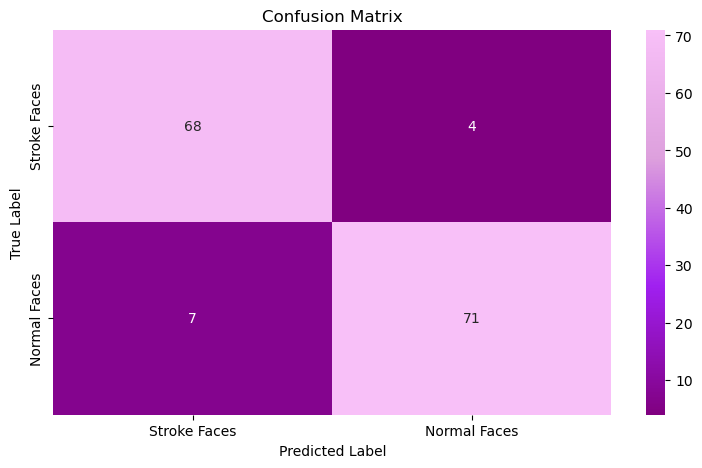

True Positive  (Correctly predicted as Stroke Face)                            :68
False Negative (Actually Stroke Face but incorrectly predicted as Normal Face) :7
True Negative  (Correctly predicted as Normal Face)                            :71
False Positive (Actually Normal Face but incorrectly predicted as Stroke Face) :4


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create a custom purple colormap
purple_cmap = mcolors.LinearSegmentedColormap.from_list('purple', ['#800080', '#a020f0', '#dda0dd', '#f8c0f8'])

# Assuming you have the predictions for normal and stroke faces
true_labels_stroke = [1] * 75  # True labels for stroke faces (1 for Stroke Face)
predicted_labels_stroke = [1] * 68 + [0] * 7  # Predicted labels for stroke faces

true_labels_normal = [0] * 75  # True labels for normal faces (0 for Normal Face)
predicted_labels_normal = [0] * 71 + [1] * 4  # Predicted labels for normal faces

# Combine true labels and predicted labels
true_labels = true_labels_normal + true_labels_stroke
predicted_labels = predicted_labels_normal + predicted_labels_stroke

# Calculate confusion matrix values
TP = sum((t == 1 and p == 1) for t, p in zip(true_labels, predicted_labels))
TN = sum((t == 0 and p == 0) for t, p in zip(true_labels, predicted_labels))
FP = sum((t == 0 and p == 1) for t, p in zip(true_labels, predicted_labels))
FN = sum((t == 1 and p == 0) for t, p in zip(true_labels, predicted_labels))

confusion_matrix_values = np.array([[TP, FP], [FN, TN]])

# Plot the confusion matrix heatmap with the custom purple colormap
plt.figure(figsize=(9, 5))
sns.heatmap(confusion_matrix_values, annot=True, fmt="d", cmap=purple_cmap, xticklabels=["Stroke Faces", "Normal Faces"], yticklabels=["Stroke Faces", "Normal Faces"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(f"True Positive  (Correctly predicted as Stroke Face)                            :{TP}")
print(f"False Negative (Actually Stroke Face but incorrectly predicted as Normal Face) :{FN}")
print(f"True Negative  (Correctly predicted as Normal Face)                            :{TN}")
print(f"False Positive (Actually Normal Face but incorrectly predicted as Stroke Face) :{FP}")

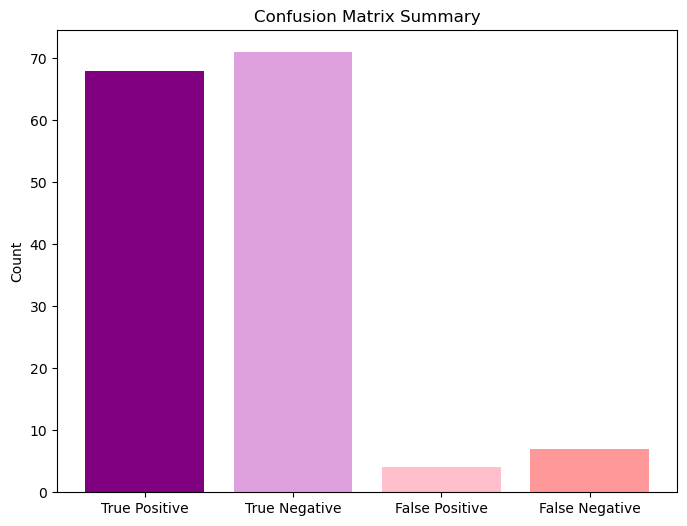

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate percentages for each category
total_samples = len(true_labels)
accuracy = (TP + TN) / total_samples
precision = TP / (TP + FP) if TP + FP != 0 else 0
recall = TP / (TP + FN) if TP + FN != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if precision + recall != 0 else 0

# Labels for the bar chart
categories = ['True Positive', 'True Negative', 'False Positive', 'False Negative']
values = [TP, TN, FP, FN]
colors = ['#800080', '#dda0dd', '#ffc0cb', '#ff9999']  # Purple and Pink colors

# Plot the bar chart
plt.figure(figsize=(8, 6))
plt.bar(categories, values, color=colors)
plt.title('Confusion Matrix Summary')
plt.ylabel('Count')
plt.show()

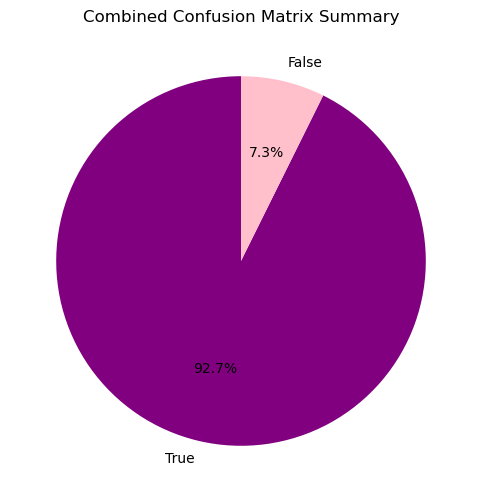

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Labels for the pie chart
labels = ['True', 'False']
sizes = [TP + TN, FP + FN]
colors = ['#800080', '#ffc0cb']  # Purple for True, Pink for False

# Plot the pie chart
plt.figure(figsize=(10, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Combined Confusion Matrix Summary')
plt.show()

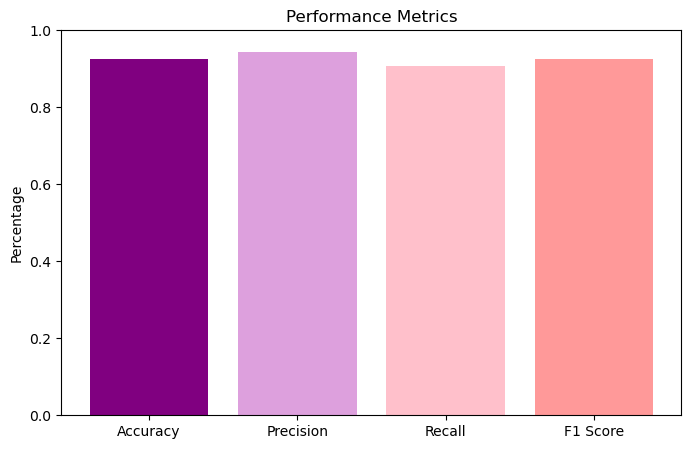

Accuracy:  92.67%
Precision: 94.44%
Recall:    90.67%
F1 Score:  92.52%


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate percentages for each metric
total_samples = len(true_labels)
accuracy = (TP + TN) / total_samples
precision = TP / (TP + FP) if TP + FP != 0 else 0
recall = TP / (TP + FN) if TP + FN != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if precision + recall != 0 else 0

# Labels for the bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1_score]
colors = ['#800080', '#dda0dd', '#ffc0cb', '#ff9999']  # Purple and Pink colors

# Plot the bar chart
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=colors)
plt.title('Performance Metrics')
plt.ylabel('Percentage')
plt.ylim(0, 1)  # Set y-axis limits to 0-100%
plt.show()

# Print additional metrics
print(f'Accuracy:  {accuracy  :.2%}')
print(f'Precision: {precision:.2%}')
print(f'Recall:    {recall:.2%}')
print(f'F1 Score:  {f1_score:.2%}')

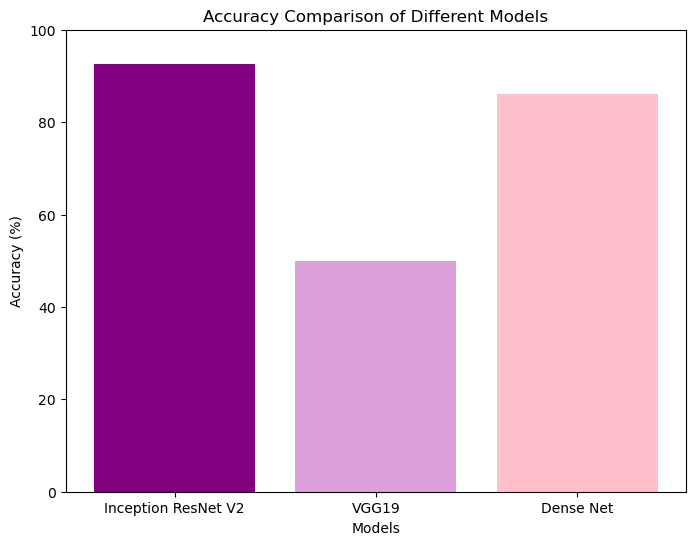

In [9]:
import matplotlib.pyplot as plt

# Data Comparison Model Between Inception Resnet V2, VGG19, Dense Net
models = ['Inception ResNet V2', 'VGG19', 'Dense Net']
accuracies = [92.67, 50, 86]

# Color for each model
colors = ['#800080', '#dda0dd', '#ffc0cb']  

# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=colors)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison of Different Models')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.show()